# Okta / Amadeus Account Deactivation — Email Sender
Fill **Cell 1** (config), then run **Cell 2** (all logic).

In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — CONFIGURATION  ← Edit here before running Cell 2
# ═══════════════════════════════════════════════════════════════

EMPLOYEE_ID      = "103550259"
TERM_DATE        = "2026-08-31"

DISPLAY_NOTEBOOK = True
SEND_EMAIL       = True

EMAIL_TO = "CNX.EXPEDIA.IDAdmins@concentrix.com;"

EMAIL_CC = (
    "puneet.suneja@concentrix.com;"
    "urmila.chakka1@concentrix.com;"
    "ML.HOC.Expedia.Hierarchy@concentrix.com;"
    "ExpediaVN_Training_Team@concentrix.com;"
    "ExpediaVN_QA_Team@concentrix.com;"
    "VN_HOC_QUANG_vn_hcm_one_exp_wfm@concentrix.com;"
    "myduyen.ly@concentrix.com;"
    "mylinh.do@concentrix.com;"
    "ashok.g@concentrix.com;"
    "suhasini.da@concentrix.com;"
    "vinay.ginka@concentrix.com;"
    "raghunath.tn@concentrix.com;"
    "van.tran@concentrix.com;"
)

[Paths]
  HC Parquet  : OK  C:/Users/huuchinh.nguyen/Concentrix Corporation/WFM-Expedia-HCM - Branding files/BI_Task/CODE/Resources/hc_extend_combination.parquet
  Capture Dir : OK  C:/Users/huuchinh.nguyen/Concentrix Corporation/WFM-Expedia-HCM - Branding files/Rawdata/CAPTURE/deactivate_capture
  HC Master DB: OK  C:/Users/huuchinh.nguyen/Concentrix Corporation/WFM-Expedia-HCM - Branding files/Headcount/HC Master Database - 2026.xlsx

[HC Parquet] Loading...
  Email : hoangmaithy.le@concentrix.com
  LOB   : Lodging

[HC Master DB] Loading Active sheet...
  ERROR loading HC Master DB: [Errno 13] Permission denied: 'C:/Users/huuchinh.nguyen/Concentrix Corporation/WFM-Expedia-HCM - Branding files/Headcount/HC Master Database - 2026.xlsx'
  Name (fallback from parquet Alias): LE HOANG MAI THY

[Summary]
  Employee ID   : 103550259
  Employee Name : LE HOANG MAI THY
  Email         : hoangmaithy.le@concentrix.com
  LOB           : Lodging
  Term Date     : 2026-08-31
  Office ID     : (no

c:\Users\huuchinh.nguyen\AppData\Local\anaconda3\Lib\site-packages\IPython\core\display.py:431: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Employee ID,LOB,Termination date,Email
103550259,Lodging,2026-08-31,hoangmaithy.le@concentrix.com

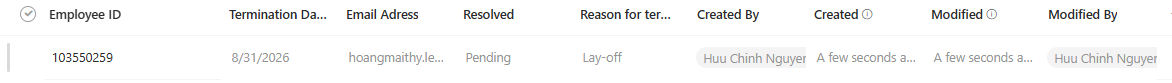

[Preview] Rendered.

  DEACTIVATION REQUEST SUMMARY
  Employee ID   : 103550259
  Employee Name : LE HOANG MAI THY
  Agent Email   : hoangmaithy.le@concentrix.com
  LOB           : Lodging
  Term Date     : 2026-08-31
  Amadeus       : NO  (no Office ID / User ID found)
  Screenshot    : C:\Users\huuchinh.nguyen\Concentrix Corporation\WFM-Expedia-HCM - Branding files\Rawdata\CAPTURE\deactivate_capture\103550259.png
--------------------------------------------------------------
  To            : CNX.EXPEDIA.IDAdmins@concentrix.com;
  CC            : puneet.suneja@concentrix.com;urmila.chakka1@concentrix.com;ML.HOC.Expedia.Hierarchy@concentrix.com;ExpediaVN_Training_Team@concentrix.com;ExpediaVN_QA_Team@concentrix.com;VN_HOC_QUANG_vn_hcm_one_exp_wfm@concentrix.com;myduyen.ly@concentrix.com;mylinh.do@concentrix.com;ashok.g@concentrix.com;suhasini.da@concentrix.com;vinay.ginka@concentrix.com;raghunath.tn@concentrix.com;van.tran@concentrix.com;
  Subject       : VN Expedia_ Account Deactiva

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — ALL LOGIC  (imports → data → preview → send)
# ═══════════════════════════════════════════════════════════════
import os, time, subprocess, pythoncom, psutil, io, base64
import pandas as pd
import polars as pl
from datetime import datetime
from pathlib import Path
from IPython.display import HTML, display

# ── Validate config ──────────────────────────────────────────
if str(EMPLOYEE_ID).strip() in ("", "?"):
    raise ValueError("EMPLOYEE_ID not set — update Cell 1 first.")

# ── Paths ────────────────────────────────────────────────────
BASE = os.path.expanduser("~").replace("\\", "/")
HC_PARQUET     = f"{BASE}/Concentrix Corporation/WFM-Expedia-HCM - Branding files/BI_Task/CODE/Resources/hc_extend_combination.parquet"
CAPTURE_FOLDER = f"{BASE}/Concentrix Corporation/WFM-Expedia-HCM - Branding files/Rawdata/CAPTURE/deactivate_capture"
HC_MASTER_DB   = f"{BASE}/Concentrix Corporation/WFM-Expedia-HCM - Branding files/Headcount/HC Master Database - 2026.xlsx"

print("[Paths]")
for label, p in [("HC Parquet  ", HC_PARQUET), ("Capture Dir ", CAPTURE_FOLDER), ("HC Master DB", HC_MASTER_DB)]:
    print(f"  {label}: {'OK' if Path(p).exists() else 'MISSING'}  {p}")

# ── LOB normalisation ────────────────────────────────────────
_LOB_MAP = {
    "Support_LG_Nesting"  : "Lodging",
    "Support_NL_Nesting"  : "Non_Lodging",
    "LG Chat CSG Training": "Training",
    "Support_Flex_SME"    : "SME",
    "Lodging"             : "Lodging",
    "Non_Lodging"         : "Non_Lodging",
    "LG Chat CSG"         : "Lodging",
}
def map_lob(v):
    return _LOB_MAP.get(str(v).strip(), str(v).strip()) if pd.notna(v) and str(v).strip() else ""

def is_empty(v):
    """True if value is blank / dash / null sentinel."""
    return str(v).strip().lower() in ("", "nan", "none", "nat", "-")

# ── Load HC Parquet ──────────────────────────────────────────
print("\n[HC Parquet] Loading...")
hc_raw = pl.read_parquet(HC_PARQUET)
hc_df  = (
    hc_raw
    .with_columns(pl.col("OracleID").cast(pl.Utf8, strict=False).str.strip_chars().alias("_oid"))
    .filter(pl.col("_oid") == str(EMPLOYEE_ID).strip())
    .sort("Date", descending=True)
    .to_pandas()
)
if hc_df.empty:
    raise ValueError(f"Employee ID '{EMPLOYEE_ID}' not found in HC parquet (OracleID column).")

hc_row      = hc_df.iloc[0]
AGENT_EMAIL = str(hc_row.get("Email Id", "")).strip()
AGENT_LOB   = map_lob(hc_row.get("LOB", ""))
print(f"  Email : {AGENT_EMAIL}")
print(f"  LOB   : {AGENT_LOB}")

# ── Load HC Master Database — Active sheet ───────────────────
print(f"\n[HC Master DB] Loading Active sheet...")
AGENT_NAME  = ""
OFFICE_ID   = ""
USER_ID     = ""
HAS_AMADEUS = False

try:
    hcm = pd.read_excel(HC_MASTER_DB, sheet_name="Active", dtype=str)
    hcm.columns = [c.strip() for c in hcm.columns.astype(str)]
    print(f"  Columns ({len(hcm.columns)}): {list(hcm.columns)}")

    oid_col  = next((c for c in hcm.columns if c.lower().replace(" ", "") == "oracleid"), None)
    name_col = next((c for c in hcm.columns if c.lower() == "employee name"), None)
    off_col  = next((c for c in hcm.columns if c.lower() == "office id"), None)
    uid_col  = next((c for c in hcm.columns if c.lower() == "user id"), None)
    print(f"  Matched — OracleID: '{oid_col}'  Name: '{name_col}'  OfficeID: '{off_col}'  UserID: '{uid_col}'")

    if oid_col:
        hcm["_oid"] = hcm[oid_col].astype(str).str.strip()
        match = hcm[hcm["_oid"] == str(EMPLOYEE_ID).strip()]

        if match.empty:
            print(f"  WARNING: ID {EMPLOYEE_ID} not found in Active sheet")
        else:
            mrow = match.iloc[0]
            if name_col and not is_empty(mrow[name_col]):
                AGENT_NAME = str(mrow[name_col]).strip()
            if off_col  and not is_empty(mrow[off_col]):
                OFFICE_ID  = str(mrow[off_col]).strip()
            if uid_col  and not is_empty(mrow[uid_col]):
                USER_ID    = str(mrow[uid_col]).strip()
            HAS_AMADEUS = bool(OFFICE_ID or USER_ID)

            print(f"  Employee Name : {AGENT_NAME or '(not found)'}")
            print(f"  Office ID     : {OFFICE_ID or '(empty/dash)'}")
            print(f"  User ID       : {USER_ID or '(empty/dash)'}")
            print(f"  => Amadeus    : {'YES' if HAS_AMADEUS else 'NO'}")
    else:
        print("  WARNING: OracleID column not found in HC Master DB")

except Exception as _e:
    print(f"  ERROR loading HC Master DB: {_e}")

if not AGENT_NAME:
    AGENT_NAME = str(hc_row.get("Employee Name", hc_row.get("Alias", EMPLOYEE_ID))).strip()
    print(f"  Name (fallback from parquet Alias): {AGENT_NAME}")

# ── Termination date ─────────────────────────────────────────
TERM_DATE_DISPLAY = TERM_DATE.strip()
if not TERM_DATE_DISPLAY:
    _tc = next((c for c in hc_df.columns if "termin" in c.lower()), None)
    if _tc:
        _tv = str(hc_row.get(_tc, "")).strip()
        TERM_DATE_DISPLAY = _tv if not is_empty(_tv) else "N/A"
    else:
        TERM_DATE_DISPLAY = "N/A"

# ── Build subject ────────────────────────────────────────────
SEND_DATE_STR = datetime.now().strftime("%d-%b-%y")
EMAIL_SUBJECT = f"VN Expedia_ Account Deactivation Request_{EMPLOYEE_ID}_{AGENT_NAME}_{SEND_DATE_STR}"

print("\n[Summary]")
print(f"  Employee ID   : {EMPLOYEE_ID}")
print(f"  Employee Name : {AGENT_NAME}")
print(f"  Email         : {AGENT_EMAIL}")
print(f"  LOB           : {AGENT_LOB}")
print(f"  Term Date     : {TERM_DATE_DISPLAY}")
print(f"  Office ID     : {OFFICE_ID or '(none)'}")
print(f"  User ID       : {USER_ID or '(none)'}")
print(f"  Amadeus       : {'YES' if HAS_AMADEUS else 'NO'}")
print(f"  Subject       : {EMAIL_SUBJECT}")

# ── Screenshot — load as-is (no crop) ───────────────────────
def load_screenshot(emp_id, folder):
    for ext in (".png", ".jpg", ".jpeg"):
        p = Path(folder) / f"{emp_id}{ext}"
        if p.exists():
            print(f"\n[Screenshot] Found: {p}")
            mime = "image/png" if ext == ".png" else "image/jpeg"
            b64  = base64.b64encode(p.read_bytes()).decode()
            return f"data:{mime};base64,{b64}", str(p.resolve())
    print(f"\n[Screenshot] NOT found: {folder}/{emp_id}.png (.jpg/.jpeg)")
    return None, None

img_b64, img_path = load_screenshot(EMPLOYEE_ID, CAPTURE_FOLDER)

# ── HTML building blocks ─────────────────────────────────────
_TH   = "border:1px solid #000;padding:6px 14px;font-weight:bold;text-align:center;"
_TD   = "border:1px solid #000;padding:6px 14px;text-align:center;"
_TBL  = "border-collapse:collapse;margin:10px 0 14px;"
_FONT = "font-family:Calibri,Arial,sans-serif;font-size:14px;color:#000;"

def _th(txt): return f'<th style="{_TH}">{txt}</th>'
def _td(txt): return f'<td style="{_TD}">{txt}</td>'

def build_table():
    headers = ["Employee ID", "LOB", "Termination date", "Email"]
    cells   = [
        EMPLOYEE_ID, AGENT_LOB, TERM_DATE_DISPLAY,
        f'<a href="mailto:{AGENT_EMAIL}" style="color:#1155CC;">{AGENT_EMAIL}</a>',
    ]
    if HAS_AMADEUS:
        headers += ["Office ID", "User ID"]
        cells   += [OFFICE_ID or "-", USER_ID or "-"]
    return (
        f'<table style="{_TBL}">'
        + "<tr>" + "".join(_th(h) for h in headers) + "</tr>"
        + "<tr>" + "".join(_td(c) for c in cells)   + "</tr>"
        + "</table>"
    )

def deact_sentence():
    hl    = 'style="background:#FFD700;"'
    not_hl = 'style="color:#CC0000;font-weight:bold;"'
    if HAS_AMADEUS:
        verb = f'<span {hl}>deactivate Okta account and Amadeus account</span>'
        return f'Please {verb} for this following case. I have submitted requests for these agents.'
    else:
        verb = f'<span {hl}>deactivate Okta account</span>'
        not_   = f'<span {not_hl}>NOT</span>'
        return f'Please {verb} and the Amadeus account does {not_} exist for this following case. I have submitted requests for these agents.'

def screenshot_html(cid_mode=False):
    style = "max-width:100%;margin-top:8px;border:1px solid #ccc;display:block;"
    if not cid_mode and img_b64:
        return f'<img src="{img_b64}" style="{style}" />'
    if cid_mode and img_path:
        return f'<img src="cid:deact_ss" style="{style}" />'
    return f'<p style="color:#c00;font-size:12px;">[Screenshot not found: {EMPLOYEE_ID}.png]</p>'

def sig_html():
    return (
        f'<div style="margin-top:18px;border-top:1px solid #ddd;padding-top:10px;{_FONT}font-size:12px;color:#555;">'
        '<p style="font-weight:bold;margin:0 0 2px;">Chinh Nguyen</p>'
        '<p style="margin:0 0 2px;">Analyst, WFM Real Time Management</p>'
        '<p style="margin:0 0 2px;line-height:1.6;">Level 4, Tower 1, OneHub Saigon, Lot C1-2, D1 Street, '
        'Saigon Hi Tech Park,<br>Tan Phu Ward, District 9, Ho Chi Minh City, Vietnam</p>'
        '<p style="margin:0;">Ph No: +84 986 473 419 &nbsp;|&nbsp; Email: '
        '<a href="mailto:huuchinh.nguyen@concentrix.com" style="color:#1155CC;">'
        'huuchinh.nguyen@concentrix.com</a></p></div>'
    )

def build_full_email(cid_mode=False):
    return (
        f'<div style="{_FONT}padding:20px 24px;background:#fff;">'
        '<p style="margin:0 0 10px;">Dear team,</p>'
        f'<p style="margin:0 0 8px;">{deact_sentence()}</p>'
        + build_table()
        + screenshot_html(cid_mode)
        + sig_html()
        + "</div>"
    )

# ── Notebook preview ─────────────────────────────────────────
if DISPLAY_NOTEBOOK:
    nb_html = (
        "<!DOCTYPE html><html><head><meta charset='utf-8'>"
        "<style>body{margin:0;background:#e8e8e8;}"
        ".wrap{max-width:860px;margin:16px auto;background:#fff;border:1px solid #ccc;}</style>"
        "</head><body><div class='wrap'>"
        + build_full_email(cid_mode=False)
        + "</div></body></html>"
    )
    esc = nb_html.replace("&","&amp;").replace('"',"&quot;").replace("'","&#39;")
    display(HTML(
        f'<iframe srcdoc="{esc}" style="width:100%;border:1px solid #ddd;border-radius:4px;min-height:400px;" '
        f'onload="this.style.height=(this.contentDocument.body.scrollHeight+30)+\'px\'"></iframe>'
    ))
    print("[Preview] Rendered.")

# ── Send email via Outlook ───────────────────────────────────
if SEND_EMAIL:
    import win32com.client

    def _send():
        pythoncom.CoInitialize()
        was_on = any(p.name().lower() == "outlook.exe" for p in psutil.process_iter(["name"]))
        if not was_on:
            for exe in [
                r"C:\Program Files\Microsoft Office\root\Office16\OUTLOOK.EXE",
                r"C:\Program Files (x86)\Microsoft Office\root\Office16\OUTLOOK.EXE",
            ]:
                if os.path.exists(exe): subprocess.Popen([exe]); break
            print("[Outlook] Starting...")
            for _ in range(30):
                time.sleep(1)
                try: win32com.client.GetActiveObject("Outlook.Application"); break
                except: pass
        try:
            ol = win32com.client.Dispatch("Outlook.Application")
            ol.GetNamespace("MAPI").Logon()
            mail          = ol.CreateItem(0)
            mail.To       = EMAIL_TO
            mail.CC       = EMAIL_CC
            mail.Subject  = EMAIL_SUBJECT
            mail.HTMLBody = build_full_email(cid_mode=True)
            if img_path and Path(img_path).exists():
                att = mail.Attachments.Add(str(Path(img_path).resolve()))
                att.PropertyAccessor.SetProperty(
                    "http://schemas.microsoft.com/mapi/proptag/0x3712001E", "deact_ss")
                print(f"[Outlook] Screenshot attached inline: {Path(img_path).name}")
            else:
                print("[Outlook] No screenshot — sending without image.")
            mail.Send()
            print(f"[Outlook] Email sent!")
            print(f"  To      : {EMAIL_TO}")
            print(f"  CC      : {EMAIL_CC}")
            print(f"  Subject : {EMAIL_SUBJECT}")
            time.sleep(2)
        finally:
            if not was_on:
                try: ol.Quit(); print("[Outlook] Closed.")
                except: pass

    # Confirm before send
    print("\n" + "="*62)
    print("  DEACTIVATION REQUEST SUMMARY")
    print("="*62)
    print(f"  Employee ID   : {EMPLOYEE_ID}")
    print(f"  Employee Name : {AGENT_NAME}")
    print(f"  Agent Email   : {AGENT_EMAIL}")
    print(f"  LOB           : {AGENT_LOB}")
    print(f"  Term Date     : {TERM_DATE_DISPLAY}")
    if HAS_AMADEUS:
        print(f"  Amadeus       : YES  |  Office ID: {OFFICE_ID}  |  User ID: {USER_ID}")
    else:
        print(f"  Amadeus       : NO  (no Office ID / User ID found)")
    print(f"  Screenshot    : {img_path or 'NOT FOUND'}")
    print("-"*62)
    print(f"  To            : {EMAIL_TO}")
    print(f"  CC            : {EMAIL_CC}")
    print(f"  Subject       : {EMAIL_SUBJECT}")
    print("="*62)

    _ans = input("\nSend EMAIL? (yes/no): ").strip().lower()
    print("="*62)
    if _ans == "yes":
        _send()
    else:
        print("[CANCELLED] Email not sent.")
else:
    print("[SKIP] SEND_EMAIL = False")